In [2]:
import os
from glob import glob
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, MultiHeadAttention # Add these imports
from tensorflow.keras import regularizers # Add this import
from tensorflow.keras import Model
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

2025-07-29 03:27:46.659624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753759666.860642      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753759666.924169      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
class SqueezeLayer(tf.keras.layers.Layer):
    def __init__(self, axis=None, **kwargs):
        super(SqueezeLayer, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.squeeze(inputs, axis=self.axis)

    def get_config(self):
        config = super(SqueezeLayer, self).get_config()
        config.update({'axis': self.axis})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [4]:
# Transformer Block
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.2, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
            Dense(d_model, kernel_regularizer=regularizers.l2(0.005))
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
        self.d_model = d_model
        self.num_heads = num_heads
        self.dff = dff
        self.rate = rate

    def call(self, x, training=False):
        attn_output = self.mha(x, x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

    def get_config(self):
        config = super(TransformerBlock, self).get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'dff': self.dff,
            'rate': self.rate
        })
        return config

    @classmethod
    def from_config(cls, config):
        config = {k: v for k, v in config.items() if k in ['d_model', 'num_heads', 'dff', 'rate']}
        return cls(**config)

# Temporal Attention Layer
class TemporalAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.query = Dense(input_shape[-1], use_bias=False)
        self.key = Dense(input_shape[-1], use_bias=False)
        self.value = Dense(input_shape[-1], use_bias=False)

    def call(self, x):
        q = self.query(x)  # (batch_size, n_frames, d_model)
        k = self.key(x)
        v = self.value(x)
        attention_scores = tf.matmul(q, k, transpose_b=True)  # (batch_size, n_frames, n_frames)
        attention_weights = tf.nn.softmax(attention_scores, axis=-1)
        attended_output = tf.matmul(attention_weights, v)  # (batch_size, n_frames, d_model)
        return tf.reduce_sum(attended_output, axis=1)  # (batch_size, d_model)

    def get_config(self):
        config = super(TemporalAttention, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [6]:

# emotions and their mapping
EMOTIONS = ['Angry', 'Happy', 'Anxiety', 'Neutral', 'Sad']
NUM_CLASSES = len(EMOTIONS)
emotion_map = {
        'Angry': 0,
        'Happy': 1,
        'Anxiety': 2,
        'Neutral': 3,
        'Sad': 4
    }
# Calculate global pitch parameters from training data
GLOBAL_MEAN_PITCH = 0.0
GLOBAL_JITTER = 0.0
GLOBAL_PITCH_SLOPE = 0.0

# function to add noise
def add_noise(audio, noise_factor=0.01):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

# function to change pitch
def pitch_shift(audio, sr, n_steps=2): # Random n_steps
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

# function to stretch audio in time
def time_stretch(audio, rate=0.95): # Random rate
    return librosa.effects.time_stretch(audio, rate=rate)

# function to shift audio in time
def time_shift(audio, shift_max=0.2, sr=24200):
    shift = int(np.random.uniform(-shift_max, shift_max) * sr)
    return np.roll(audio, shift)

# normalize_pitch function
def normalize_pitch(pitches):
    pitches = pitches[pitches > 0]
    if len(pitches) == 0:
        return GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE

    mean_pitch = np.mean(pitches)
    normalized_pitches = pitches - mean_pitch
    jitter = np.std(normalized_pitches) if len(normalized_pitches) > 0 else 0

    # Check if there are enough points for polyfit
    if len(pitches) > 1:
        slope = np.polyfit(np.arange(len(pitches)), pitches, 1)[0]
    else:
        slope = 0 # Fallback for single point

    # Handle NaN values that might arise from edge cases
    if np.isnan(mean_pitch): mean_pitch = GLOBAL_MEAN_PITCH
    if np.isnan(jitter): jitter = GLOBAL_JITTER
    if np.isnan(slope): slope = GLOBAL_PITCH_SLOPE

    return mean_pitch, jitter, slope

# extract features from audio file
# This function extracts various audio features including MFCCs, pitch, energy, zero-crossing rate, chroma, spectral features, and temporal features.
# It also applies data augmentation techniques 
def extract_features(audio_path, sample_rate=24200, duration=10, n_mfcc=26, n_frames=157, augment_type='normal', global_pitch_params=None):
    try:
        audio, sr = librosa.load(audio_path, sr=sample_rate)
        target_length = sample_rate * duration

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            audio = audio[:target_length]

        if augment_type == 'noise':
            audio = add_noise(audio)
        elif augment_type == 'pitch':
            audio = pitch_shift(audio, sr)
        elif augment_type == 'stretch':
            audio = time_stretch(audio)
        elif augment_type == 'shift':
            audio = time_shift(audio)

        hop_length = target_length // (n_frames - 1)

        # MFCCs + Delta + Delta-Delta
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length, n_fft=2048)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        mfcc_features = np.concatenate((mfcc, mfcc_delta, mfcc_delta2), axis=0)

        # Pad or truncate MFCCs
        if mfcc_features.shape[1] > n_frames:
            mfcc_features = mfcc_features[:, :n_frames]
        elif mfcc_features.shape[1] < n_frames:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, n_frames - mfcc_features.shape[1])), mode='constant')

        # Pitch features
        pitches, magnitudes = librosa.piptrack(y=audio, sr=sr, hop_length=hop_length)
        if global_pitch_params:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches)
            # If normalize_pitch returns fallback values (0,0,0), use global defaults
            if mean_pitch == 0 and jitter == 0 and pitch_slope == 0:
                mean_pitch, jitter, pitch_slope = global_pitch_params
        else:
            mean_pitch, jitter, pitch_slope = normalize_pitch(pitches) # Will use current GLOBAL_*

        pitch_features_single = np.array([mean_pitch, jitter, pitch_slope])
        pitch_features = np.tile(pitch_features_single, (n_frames, 1)).T # Tile to match n_frames

        # Energy features (RMS + mean and std)
        energy = librosa.feature.rms(y=audio, hop_length=hop_length)[0]
        if len(energy) > n_frames:
            energy = energy[:n_frames]
        elif len(energy) < n_frames:
            energy = np.pad(energy, (0, n_frames - len(energy)), mode='constant')

        mean_energy = np.mean(energy)
        shimmer = np.std(energy) if len(energy) > 0 else 0
        energy_features = np.array([energy, np.full(n_frames, mean_energy), np.full(n_frames, shimmer)])

        # Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=hop_length)[0]
        if len(zcr) > n_frames:
            zcr = zcr[:n_frames]
        elif len(zcr) < n_frames:
            zcr = np.pad(zcr, (0, n_frames - len(zcr)), mode='constant')
        zcr_features = zcr[np.newaxis, :]

        # Chroma features
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=hop_length, n_chroma=12)
        if chroma.shape[1] > n_frames:
            chroma = chroma[:, :n_frames]
        elif chroma.shape[1] < n_frames:
            chroma = np.pad(chroma, ((0, 0), (0, n_frames - chroma.shape[1])), mode='constant')

        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=hop_length)[0]
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, hop_length=hop_length, n_bands=5)

        # Pad or truncate spectral features
        # Assuming all spectral features have the same number of frames
        if spectral_centroid.shape[0] > n_frames:
            spectral_centroid = spectral_centroid[:n_frames]
            spectral_rolloff = spectral_rolloff[:n_frames]
            spectral_contrast = spectral_contrast[:, :n_frames]
        elif spectral_centroid.shape[0] < n_frames:
            spectral_centroid = np.pad(spectral_centroid, (0, n_frames - spectral_centroid.shape[0]), mode='constant')
            spectral_rolloff = np.pad(spectral_rolloff, (0, n_frames - spectral_rolloff.shape[0]), mode='constant')
            spectral_contrast = np.pad(spectral_contrast, ((0, 0), (0, n_frames - spectral_contrast.shape[1])), mode='constant')
        spectral_features = np.vstack([spectral_centroid, spectral_rolloff, spectral_contrast])

        # Temporal features
        voiced_frames = librosa.effects.split(audio, top_db=20)
        speech_rate = len(voiced_frames) / (duration if duration > 0 else 1)
        pauses = len(voiced_frames) - 1 if len(voiced_frames) > 1 else 0
        temporal_features_single = np.array([speech_rate, pauses])
        temporal_features = np.tile(temporal_features_single, (n_frames, 1)).T

        features = np.concatenate([
            mfcc_features, # Now includes delta and delta-delta
            pitch_features,
            energy_features,
            zcr_features,
            chroma,
            spectral_features,
            temporal_features
        ], axis=0)

        return np.expand_dims(features, axis=-1)

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# build transformer model
def build_transformer_model(input_shape, num_classes=NUM_CLASSES):
    # input_shape here is (num_features, n_frames, 1)
    inputs = layers.Input(shape=input_shape)

    # Use the custom SqueezeLayer instead of direct tf.squeeze
    x = SqueezeLayer(axis=-1)(inputs) # Shape becomes (batch_size, num_features, n_frames)

    # Transpose to (batch_size, n_frames, num_features) to align with transformer expectation (sequence_length, feature_dimension)
    x = layers.Permute((2, 1))(x)

    # Apply a Dense layer to project to d_model (128)
    # The input to the Transformer Block should be (batch_size, sequence_length, d_model)
    # Here, sequence_length is n_frames and d_model is the output of this Dense layer
    d_model = 128
    x = layers.Dense(d_model, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x)

    # Add positional encoding
    pos_encoding = positional_encoding(input_shape[1], d_model) # input_shape[1] is n_frames
    x = x + pos_encoding

    # Stack 3 Transformer blocks
    for _ in range(3):
        x = TransformerBlock(d_model=d_model, num_heads=8, dff=256, rate=0.2)(x, training=True)

    # Add Temporal Attention
    x = TemporalAttention()(x)

    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.005))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.summary()
    return model

# Positional Encoding
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rads = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

def train_with_kfold(X, y, n_splits=5, epochs=200, batch_size=16, class_weight=None):
    """
    Trains and evaluates the model using K-Fold cross-validation.

    Args:
        X (np.array): Feature data.
        y (np.array): Label data.
        n_splits (int): The number of folds (k).
        epochs (int): Number of training epochs for each fold.
        batch_size (int): Batch size for training.
        class_weight (dict): Weights for handling class imbalance.

    Returns:
        tuple: A tuple containing lists of histories and validation scores from each fold.
    """
    # Initialize KFold
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Lists to store results from each fold
    all_histories = []
    all_val_scores = []
    fold_no = 1

    # Main loop for k-fold cross-validation
    for train_index, val_index in kfold.split(X, np.argmax(y, axis=1)):
        print(f'----------------- Training Fold {fold_no} -----------------')

        # Split data for the current fold
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # 1. Build a new model instance for each fold to avoid weight leakage
        input_shape = X_train.shape[1:]
        model = build_transformer_model(input_shape=input_shape, num_classes=y.shape[1])

        # 2. Compile the model
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                      metrics=['accuracy'])

        # 3. Define callbacks
        checkpoint_path = f'best_model_fold_{fold_no}.h5'
        early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001)
        checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)

        # 4. Train the model
        history = model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=epochs,
                            batch_size=batch_size,
                            callbacks=[early_stopping, reduce_lr, checkpoint],
                            class_weight=class_weight,
                            verbose=1)

        # 5. Evaluate the model on the validation set
        val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
        print(f'\nScore for fold {fold_no}: Loss={val_loss:.4f}, Accuracy={val_accuracy:.4f}')

        # 6. Store results
        all_histories.append(history)
        all_val_scores.append((val_loss, val_accuracy))
        fold_no += 1

    # --- Print Average Results ---
    print('\n----------------- K-Fold Cross-Validation Summary -----------------')
    avg_loss = np.mean([score[0] for score in all_val_scores])
    avg_acc = np.mean([score[1] for score in all_val_scores])
    print(f'Average Validation Loss: {avg_loss:.4f}')
    print(f'Average Validation Accuracy: {avg_acc:.4f}')
    print('-------------------------------------------------------------------')

    return all_histories, all_val_scores
    
# train and evaluate the model
def train_and_evaluate_model(model, X, y, epochs=200, batch_size=32, checkpoint_path='best_transformer_vnemos.h5'):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
                  metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max')
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

    class_weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=np.argmax(y, axis=1))
    class_weight_dict = dict(enumerate(class_weights))

    #history = model.fit(X_train, y_train,
    #                    validation_data=(X_val, y_val),
    #                    epochs=epochs,
    #                    batch_size=batch_size,
    #                    callbacks=[early_stopping, reduce_lr, checkpoint],
    #                    class_weight=class_weight_dict,
    #                    verbose=1)
    history, score = train_with_kfold(X, y, n_splits=5, epochs=epochs, batch_size=batch_size, class_weight=class_weight_dict)

    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"\nĐánh giá trên tập kiểm tra: Loss={val_loss:.4f}, Accuracy={val_accuracy:.4f}")
    return model, history

# calculate global pitch parameters from audio files
def calculate_global_pitch_params(audio_files, sample_rate=24200):
    all_pitches = []
    for audio_path in audio_files:
        try:
            audio, sr = librosa.load(audio_path, sr=sample_rate)
            pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
            pitches = pitches[pitches > 0]
            if len(pitches) > 0:
                all_pitches.extend(pitches)
        except Exception as e:
            print(f"Error calculating global pitch for {audio_path}: {e}")
            continue

    if len(all_pitches) == 0:
        print("Warning: No valid pitches found to calculate global parameters. Using default zeros.")
        return 0.0, 0.0, 0.0

    all_pitches = np.array(all_pitches)
    global_mean_pitch = np.mean(all_pitches)

    normalized_all_pitches = all_pitches - global_mean_pitch
    global_jitter = np.std(normalized_all_pitches) if len(normalized_all_pitches) > 0 else 0

    # Calculate global pitch slope (simple average of local slopes, or fit a line to all pitches)
    # For simplicity, let's use the average of slopes calculated over reasonable segments
    # A more robust approach might involve fitting a trend line to all valid pitch values,
    # but that's computationally intensive. For global, a simple average might suffice or set to 0.
    global_pitch_slope = 0.0 # Often jitter is more informative than overall slope for global

    # Consider replacing NaN/inf with 0 in case of edge issues
    global_mean_pitch = 0.0 if np.isnan(global_mean_pitch) or np.isinf(global_mean_pitch) else global_mean_pitch
    global_jitter = 0.0 if np.isnan(global_jitter) or np.isinf(global_jitter) else global_jitter
    global_pitch_slope = 0.0 if np.isnan(global_pitch_slope) or np.isinf(global_pitch_slope) else global_pitch_slope

    return global_mean_pitch, global_jitter, global_pitch_slope


# function to prepare training data with emotion mapping
def prepare_training_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    augment_types = ['normal', 'noise', 'pitch', 'stretch', 'shift']
    skipped_files = 0
    processed_files = 0

    print(f"Tổng số file âm thanh: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            # print(f"Warning: {audio_path} có folder không hợp lệ ({folder_name}), bỏ qua.")
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]

        for aug_type in augment_types:
            features = extract_features(str(audio_path), augment_type=aug_type, global_pitch_params=global_pitch_params)
            if features is None or np.all(features == 0):
                # print(f"Warning: Không thể trích xuất đặc trưng từ {audio_path} (aug_type: {aug_type})")
                continue
            X.append(features)
            y.append(emotion_idx)
            processed_files += 1

    print(f"Đã xử lý: {processed_files} mẫu, bỏ qua: {skipped_files} file.")
    if not X or not y:
        raise ValueError("Không có file âm thanh nào được xử lý thành công. Kiểm tra đường dẫn dữ liệu hoặc emotion_map.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# prepare test data with emotion mapping
def prepare_test_data(audio_files, emotion_map, global_pitch_params):
    X, y = [], []
    skipped_files = 0
    processed_files = 0

    print(f"Tổng số file âm thanh kiểm tra: {len(audio_files)}")
    for audio_path in audio_files:
        folder_name = os.path.basename(os.path.dirname(audio_path))
        if folder_name not in emotion_map:
            # print(f"Warning: {audio_path} có folder không hợp lệ ({folder_name}), bỏ qua.")
            skipped_files += 1
            continue
        emotion_idx = emotion_map[folder_name]
        features = extract_features(str(audio_path), augment_type='normal', global_pitch_params=global_pitch_params)
        if features is None or np.all(features == 0):
            # print(f"Warning: Không thể trích xuất đặc trưng từ {audio_path}")
            continue
        X.append(features)
        y.append(emotion_idx)
        processed_files += 1

    print(f"Đã xử lý: {processed_files} mẫu, bỏ qua: {skipped_files} file.")
    if not X or not y:
        raise ValueError("Không có file âm thanh kiểm tra nào được xử lý thành công.")

    X = np.array(X)
    y = to_categorical(y, num_classes=NUM_CLASSES)
    print(f"Test dataset shape: X={X.shape}, y={y.shape}")
    return X, y

# evaluate model with confusion matrix and F1 Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    # Print sample probabilities for debugging
    print("\nSample prediction probabilities:")
    for i in range(min(5, len(X_test))):
        print(f"Sample {i+1}: True={EMOTIONS[y_true_classes[i]]}, Pred={EMOTIONS[y_pred_classes[i]]}, Prob={y_pred[i]}")

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns_heatmap  = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=EMOTIONS))

    print("\nCông thức các số liệu đánh giá:")
    print("1. Precision = TP / (TP + FP)")
    print("   - TP (True Positives): Số mẫu dự đoán đúng cho một lớp.")
    print("   - FP (False Positives): Số mẫu dự đoán sai là lớp đó.")
    print("2. Recall = TP / (TP + FN)")
    print("   - FN (False Negatives): Số mẫu thuộc lớp đó nhưng dự đoán sai.")
    print("3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)")

# train and evaluate the model
def train_and_evaluate_model(model, X, y, epochs=200, batch_size=16, checkpoint_path='best_model.h5', class_weight=None):
    if len(X) == 0 or len(y) == 0:
        raise ValueError("Tập dữ liệu huấn luyện rỗng. Kiểm tra dữ liệu đầu vào.")

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}")

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=0.00001)
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1)

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[early_stopping, reduce_lr, checkpoint],
                        class_weight=class_weight,
                        verbose=1)

    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"\nĐánh giá trên tập kiểm tra:")
    print(f" - Loss: {val_loss:.4f}")
    print(f" - Accuracy: {val_accuracy:.4f}")
    return model, history, X_val, y_val

# predict emotion from audio
def predict_emotion(audio_path, model, scaler, global_pitch_params):
    features = extract_features(audio_path, augment_type='normal', global_pitch_params=global_pitch_params)
    if features is None or np.all(features == 0):
        return "Không thể dự đoán: Lỗi trích xuất đặc trưng."

    # Reshape features for scaling
    original_shape = features.shape
    features_2d = features.reshape(1, -1)
    features_2d = scaler.transform(features_2d)  # Apply scaler
    features = features_2d.reshape(original_shape) # Reshape back

    features = np.expand_dims(features, axis=0) # Add batch dimension
    prediction = model.predict(features, verbose=0)
    predicted_emotion_idx = np.argmax(prediction, axis=1)[0]

    # Print probabilities for debugging
    print(f"Prediction probabilities for {audio_path}: {prediction[0]}")
    return EMOTIONS[predicted_emotion_idx]

# draw loss history
def plot_loss_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()



In [7]:
if __name__ == "__main__":
    # --- 1. Tải dữ liệu và tính toán các tham số Global ---
    root_folder = '/kaggle/input/speech-emotion-10/VESC/VESC'
    folders = [f for f in glob(os.path.join(root_folder, "*")) if os.path.isdir(f)]
    all_files = []
    for folder in folders:
        files = glob(os.path.join(folder, "**", "*.wav"), recursive=True)
        all_files.extend(files)
        print(f"Found {len(files)} files in folder: {os.path.basename(folder)}")

    if not all_files:
        raise ValueError("Không tìm thấy file âm thanh nào trong thư mục huấn luyện.")

    print("Calculating GLOBAL_PITCH_PARAMS from training data...")
    GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE = calculate_global_pitch_params(all_files)
    global_pitch_params = (GLOBAL_MEAN_PITCH, GLOBAL_JITTER, GLOBAL_PITCH_SLOPE)
    print(f"GLOBAL_PITCH_PARAMS: {global_pitch_params}")

    # Lấy nhãn thô để thực hiện Stratified K-Fold
    y_raw = [emotion_map.get(os.path.basename(os.path.dirname(f))) for f in all_files]
    
    # Chuyển đổi all_files và y_raw thành numpy array để dễ dàng indexing
    all_files = np.array(all_files)
    y_raw = np.array(y_raw)

    print("Phân bố nhãn gốc:", Counter([EMOTIONS[i] for i in y_raw]))
    
    # --- 2. Thiết lập K-Fold Cross-Validation ---
    N_SPLITS = 5  # Số lượng fold, bạn có thể thay đổi (ví dụ: 5 hoặc 10)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    fold_no = 1
    histories = []
    val_accuracies = []
    val_losses = []

    for train_index, val_index in skf.split(all_files, y_raw):
        print(f"--- Đang huấn luyện FOLD {fold_no}/{N_SPLITS} ---")

        # Chia file paths cho train và validation
        train_files, val_files = all_files[train_index], all_files[val_index]
        
        # --- 3. Chuẩn bị dữ liệu cho FOLD hiện tại ---
        print(f"Preparing training data for fold {fold_no} (with augmentation)...")
        # Dữ liệu training được tạo với augmentation
        X_train, y_train = prepare_training_data(train_files.tolist(), emotion_map, global_pitch_params)

        print(f"Preparing validation data for fold {fold_no} (without augmentation)...")
        # Dữ liệu validation được tạo không có augmentation
        X_val, y_val = prepare_test_data(val_files.tolist(), emotion_map, global_pitch_params)

        # --- 4. Chuẩn hóa dữ liệu (Fit trên train, transform trên cả train và val) ---
        scaler = StandardScaler()
        # Reshape cho scaler (2D)
        X_train_2d = X_train.reshape(X_train.shape[0], -1)
        # Fit scaler CHỈ trên dữ liệu training
        scaler.fit(X_train_2d)
        
        # Transform cả hai tập
        X_train_2d = scaler.transform(X_train_2d)
        X_val_2d = X_val.reshape(X_val.shape[0], -1)
        X_val_2d = scaler.transform(X_val_2d)
        
        # Reshape về lại shape cũ
        X_train = X_train_2d.reshape(X_train.shape)
        X_val = X_val_2d.reshape(X_val.shape)

        # --- 5. Xây dựng và Huấn luyện mô hình cho FOLD hiện tại ---
        transformer_input_shape = (X_train.shape[1], X_train.shape[2], 1)
        model = build_transformer_model(input_shape=transformer_input_shape)
        
        # Tính class weight cho tập train của fold này
        y_train_labels = np.argmax(y_train, axis=1)
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
        class_weight_dict = dict(enumerate(class_weights))

        checkpoint_path = f'best_model_fold_{fold_no}.keras'
        
        # Sử dụng hàm train_and_evaluate_model đã được sửa đổi một chút để không tự chia train/test
        # (Giả sử bạn đã sửa hàm train_and_evaluate_model để nhận trực tiếp X_train, y_train, X_val, y_val)
        # Nếu chưa, có thể gọi trực tiếp model.fit() tại đây.
        
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                      metrics=['accuracy'])

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max')
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
        checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

        history = model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=100, # Số epochs cho mỗi fold
                            batch_size=16,
                            callbacks=[early_stopping, reduce_lr, checkpoint],
                            class_weight=class_weight_dict,
                            verbose=1)
        
        # --- 6. Lưu kết quả của FOLD ---
        val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
        print(f"Score for fold {fold_no}: Loss={val_loss:.4f}, Accuracy={val_accuracy:.4f}")
        
        val_accuracies.append(val_accuracy)
        val_losses.append(val_loss)
        histories.append(history)

        fold_no += 1

    # --- 7. Tổng hợp và hiển thị kết quả Cross-Validation ---
    print("\n--- K-Fold Cross-Validation Results ---")
    print(f"Scores for each fold: {val_accuracies}")
    print(f"Average Accuracy: {np.mean(val_accuracies):.4f} (+/- {np.std(val_accuracies):.4f})")
    print(f"Average Loss: {np.mean(val_losses):.4f}")
    
    # --- 8. (Tùy chọn) Huấn luyện mô hình cuối cùng trên toàn bộ dữ liệu ---
    print("\n--- Training final model on ALL data ---")
    # Chuẩn bị toàn bộ dữ liệu training (với augmentation)
    X_full, y_full = prepare_training_data(all_files.tolist(), emotion_map, global_pitch_params)
    
    # Chuẩn hóa trên toàn bộ dữ liệu
    scaler_final = StandardScaler()
    X_full_2d = X_full.reshape(X_full.shape[0], -1)
    X_full_2d = scaler_final.fit_transform(X_full_2d) # Fit và transform
    X_full = X_full_2d.reshape(X_full.shape)
    
    final_input_shape = (X_full.shape[1], X_full.shape[2], 1)
    final_model = build_transformer_model(input_shape=final_input_shape)
    
    y_full_labels = np.argmax(y_full, axis=1)
    final_class_weights = compute_class_weight('balanced', classes=np.unique(y_full_labels), y=y_full_labels)
    final_class_weight_dict = dict(enumerate(final_class_weights))
    
    
                        


Found 144 files in folder: Angry
Found 164 files in folder: Neutral
Found 109 files in folder: Anxiety
Found 141 files in folder: Sad
Found 114 files in folder: Happy
Calculating GLOBAL_PITCH_PARAMS from training data...
GLOBAL_PITCH_PARAMS: (1314.3724, 1039.1417, 0.0)
Phân bố nhãn gốc: Counter({'Neutral': 164, 'Angry': 144, 'Sad': 141, 'Happy': 114, 'Anxiety': 109})
--- Đang huấn luyện FOLD 1/5 ---
Preparing training data for fold 1 (with augmentation)...
Tổng số file âm thanh: 537
Đã xử lý: 2685 mẫu, bỏ qua: 0 file.
Dataset shape: X=(2685, 107, 157, 1), y=(2685, 5)
Preparing validation data for fold 1 (without augmentation)...
Tổng số file âm thanh kiểm tra: 135
Đã xử lý: 135 mẫu, bỏ qua: 0 file.
Test dataset shape: X=(135, 107, 157, 1), y=(135, 5)


I0000 00:00:1753760038.985966      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 107, 157, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ squeeze_layer (SqueezeLayer)    │ (None, 107, 157)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 157, 107)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 157, 128)       │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 157, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 157, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 157, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 157, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (None, 128)            │        49,152 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,029 (2.02 MB)

...

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 107, 157, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ squeeze_layer_5 (SqueezeLayer)  │ (None, 107, 157)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_5 (Permute)             │ (None, 157, 107)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 157, 128)       │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_5 (Add)                     │ (None, 157, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_15            │ (None, 157, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_16            │ (None, 157, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_17            │ (None, 157, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention_5            │ (None, 128)            │        49,152 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,029 (2.02 MB)

 Trainable params: 529,029 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
206/210 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9800 - loss: 2.4823
Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to best_model_fold_5.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.9800 - loss: 2.4810 - val_accuracy: 1.0000 - val_loss: 2.2605 - learning_rate: 1.0000e-04
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9866 - loss: 2.2869
Epoch 2: val_accuracy did not improve from 1.00000
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9866 - loss: 2.2867 - val_accuracy: 1.0000 - val_loss: 2.1005 - learning_rate: 1.0000e-04
Epoch 3/100
206/210 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9947 - loss: 2.1220
Epoch 3: val_accuracy did not improve from 1.00000
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9946 - loss: 2.1212 - val_accuracy: 1.0000 - val_loss: 1.9618 - learning_rate: 1.0000e-04
Epoch 4/100
206/210 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9931 - loss: 1.9906
Epoch 4: val_a

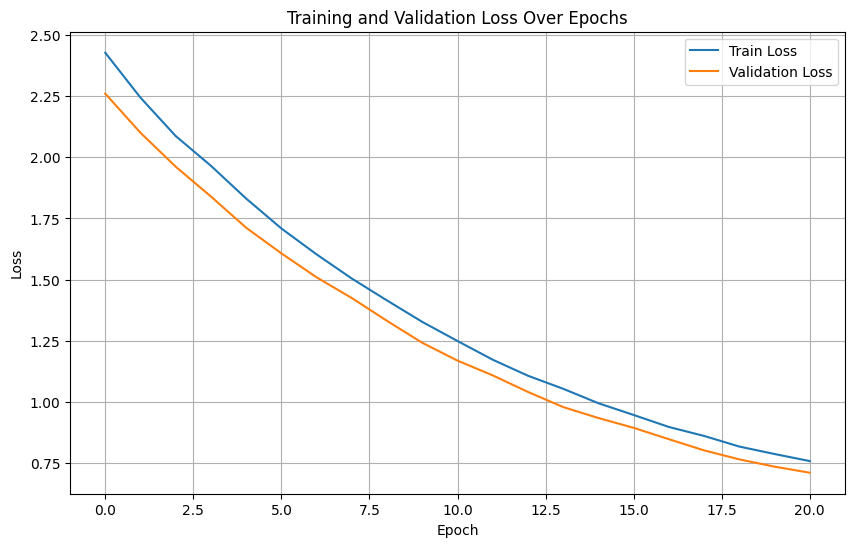

Final model trained on all data and saved as 'final_transformer_vesc_retrained.keras'

--- Evaluating final model on the TEST SET ---
Tổng số file âm thanh kiểm tra: 232
Đã xử lý: 232 mẫu, bỏ qua: 0 file.
Test dataset shape: X=(232, 107, 157, 1), y=(232, 5)
Evaluating the final retrained model:

Sample prediction probabilities:
Sample 1: True=Angry, Pred=Angry, Prob=[0.96204907 0.00494228 0.00422743 0.02490118 0.0038802 ]
Sample 2: True=Angry, Pred=Angry, Prob=[0.9357348  0.01761605 0.01432329 0.01734261 0.01498323]
Sample 3: True=Angry, Pred=Angry, Prob=[0.82610583 0.07369086 0.01125693 0.06471144 0.024235  ]
Sample 4: True=Angry, Pred=Angry, Prob=[9.9694544e-01 8.0491701e-04 2.4984308e-04 1.4095497e-03 5.9030933e-04]
Sample 5: True=Angry, Pred=Angry, Prob=[0.85732555 0.03733311 0.04133268 0.03805654 0.02595211]


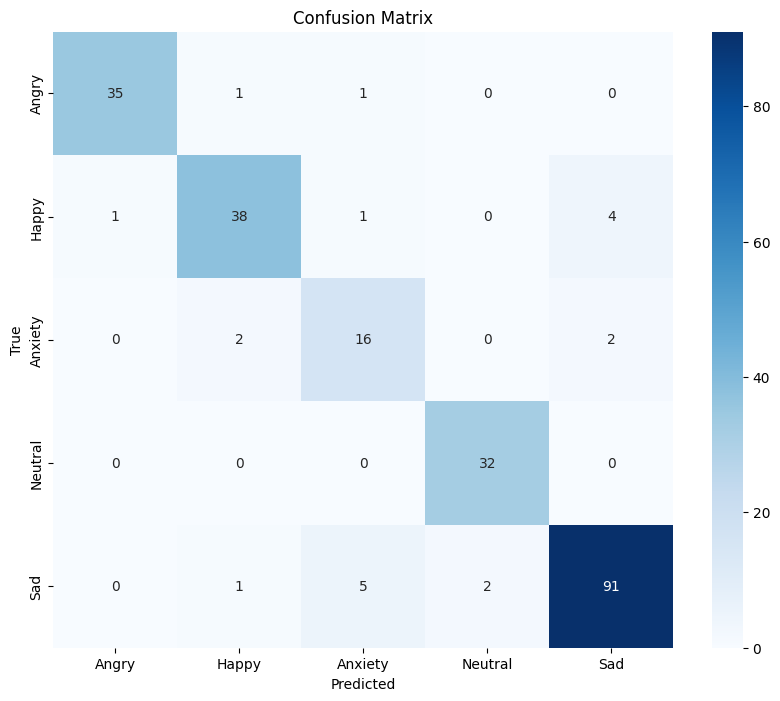


Classification Report:
              precision    recall  f1-score   support

       Angry       0.97      0.95      0.96        37
       Happy       0.90      0.86      0.88        44
     Anxiety       0.70      0.80      0.74        20
     Neutral       0.94      1.00      0.97        32
         Sad       0.94      0.92      0.93        99

    accuracy                           0.91       232
   macro avg       0.89      0.91      0.90       232
weighted avg       0.92      0.91      0.91       232


Công thức các số liệu đánh giá:
1. Precision = TP / (TP + FP)
   - TP (True Positives): Số mẫu dự đoán đúng cho một lớp.
   - FP (False Positives): Số mẫu dự đoán sai là lớp đó.
2. Recall = TP / (TP + FN)
   - FN (False Negatives): Số mẫu thuộc lớp đó nhưng dự đoán sai.
3. F1 Score = 2 * (Precision * Recall) / (Precision + Recall)


In [11]:

    X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
    )
    # Không cần validation data khi huấn luyện trên toàn bộ tập dữ liệu
    # Bạn cũng có thể bỏ early stopping hoặc đặt monitor là 'loss'
    final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                        metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max')
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    history_final = final_model.fit(X_full, y_full,
                    epochs=100, # Bạn có thể điều chỉnh số epochs dựa trên kết quả K-Fold
                    batch_size=16,
                    callbacks=[early_stopping, reduce_lr, checkpoint],
                    class_weight=final_class_weight_dict,
                    verbose=1,
                    validation_data=(X_val_final, y_val_final)                
                    )
    
    plot_loss_history(history_final)
    
    final_model.save('final_transformer_vesc_retrained.keras')
    print("Final model trained on all data and saved as 'final_transformer_vesc_retrained.keras'")

    # --- 9. Đánh giá mô hình cuối cùng trên tập Test riêng biệt ---
    print("\n--- Evaluating final model on the TEST SET ---")
    root_folder_test = "/kaggle/input/speech-emotion-10/VESC_test/VESC_test"
    # ... (code để tải dữ liệu test như cũ) ...
    all_files_test = [] # Giả sử đã điền dữ liệu
    for folder in glob(os.path.join(root_folder_test, "*")):
        if os.path.isdir(folder):
            files = glob(os.path.join(folder, "**", "*.wav"), recursive=True)
            all_files_test.extend(files)

    if not all_files_test:
        print("Warning: Không tìm thấy file âm thanh nào trong thư mục kiểm tra.")
    else:
        X_test_final, y_test_final = prepare_test_data(all_files_test, emotion_map, global_pitch_params)
        
        # Chuẩn hóa dữ liệu test với scaler đã được fit trên toàn bộ dữ liệu training
        X_test_final_2d = X_test_final.reshape(X_test_final.shape[0], -1)
        X_test_final_2d = scaler_final.transform(X_test_final_2d) # Chỉ transform
        X_test_final = X_test_final_2d.reshape(X_test_final.shape)
        
        print("Evaluating the final retrained model:")
        evaluate_model(final_model, X_test_final, y_test_final)